# Setup

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib fairlearn shap xgboost kagglehub
import sys
sys.path.insert(0, ".")   # makes `src` importable; use "/content" on Colab

You should consider upgrading via the '/Users/Mutru001/Library/Mobile Documents/com~apple~CloudDocs/Personal/UU (cloud)/Period 4/Human Centered ML/project/venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import sys
import importlib

# Clear cached config so it re-evaluates xgboost
if 'src.config' in sys.modules:
    del sys.modules['src.config']

from src.config import *

/Users/Mutru001/Library/Mobile Documents/com~apple~CloudDocs/Personal/UU (cloud)/Period 4/Human Centered ML/project/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# from google.colab import drive
# drive.mount('/content/drive')

# Load data

In [3]:
from src.data_loader import resolve_data_dir, load_all_tables, inspect_tables
DATA_DIR = resolve_data_dir()
tables = load_all_tables(DATA_DIR)
inspect_tables(tables["student_info"], tables["courses"])

Downloaded dataset to: /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1
Reading courses.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/courses.csv
Reading assessments.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/assessments.csv
Reading studentAssessment.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/studentAssessment.csv
Reading studentInfo.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/studentInfo.csv
Reading studentRegistration.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/studentRegistration.csv
Reading studentVle.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/

In [4]:
from src.feature_engineering import build_base_table, build_dataset_for_stage
base = build_base_table(tables["student_info"], tables["courses"])
early_df = build_dataset_for_stage(
    base, tables["student_vle"], tables["vle"], tables["courses"],
    tables["student_assess"], tables["assessments"], tables["student_reg"],
    fraction=0.25, stage_name="early_25pct"
)
full_df = build_dataset_for_stage(
    base, tables["student_vle"], tables["vle"], tables["courses"],
    tables["student_assess"], tables["assessments"], tables["student_reg"],
    fraction=1.00, stage_name="full_100pct"
)
display(early_df.head()); display(full_df.head())


Base table shape: (32593, 14)
Target distribution:
target_unsuccessful
1    17208
0    15385
Name: count, dtype: int64
target_unsuccessful
1    0.527966
0    0.472034
Name: proportion, dtype: float64

Building dataset for early_25pct, fraction=0.25
VLE features: (28360, 18)
Assessment features: (25444, 11)
Registration features: (32593, 6)
Final stage table: (32593, 39)

Building dataset for full_100pct, fraction=1.0
VLE features: (28500, 18)
Assessment features: (25843, 11)
Registration features: (32593, 6)
Final stage table: (32593, 39)


,code_module,code_presentation,id_student,target_unsuccessful,module_presentation_length,gender,age_band,highest_education,imd_band,region,num_of_prev_attempts,studied_credits,date_registration,registered_before_start,days_registered_before_start,vle_total_clicks,vle_active_days,vle_mean_clicks_per_record,vle_max_clicks_per_record,vle_num_records,vle_clicks_per_active_day,clicks_forumng,clicks_homepage,clicks_other_activity,clicks_oucontent,clicks_ouwiki,clicks_quiz,clicks_resource,clicks_subpage,clicks_url,assess_num_submitted,assess_mean_score,assess_min_score,assess_max_score,assess_weighted_score_sum,assess_total_weight_seen,assess_late_rate,assess_mean_days_before_due,stage
0,AAA,2013J,11391,0,268,M,55<=,HE Qualification,90-100%,East Anglian Region,0,240,-159.0,1.0,159.0,447.0,18.0,5.518519,76.0,81.0,24.833333,96.0,63.0,0.0,266.0,0.0,0.0,9.0,12.0,1.0,2.0,81.5,78.0,85.0,24.8,30.0,0.0,1.0,early_25pct
1,AAA,2013J,28400,0,268,F,35-55,HE Qualification,20-30%,Scotland,0,60,-53.0,1.0,53.0,508.0,22.0,3.479452,19.0,146.0,23.090909,181.0,114.0,0.0,148.0,0.0,0.0,0.0,39.0,26.0,2.0,69.0,68.0,70.0,20.6,30.0,0.5,-0.5,early_25pct
2,AAA,2013J,30268,1,268,F,35-55,A Level or Equivalent,30-40%,North Western Region,0,60,-92.0,1.0,92.0,179.0,6.0,4.261905,23.0,42.0,29.833333,87.0,27.0,0.0,52.0,0.0,0.0,0.0,10.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,early_25pct
3,AAA,2013J,31604,0,268,F,35-55,A Level or Equivalent,50-60%,South East Region,0,60,-52.0,1.0,52.0,710.0,38.0,3.212670,13.0,221.0,18.684211,205.0,159.0,0.0,250.0,0.0,0.0,1.0,59.0,36.0,2.0,71.5,71.0,72.0,21.4,30.0,0.0,2.5,early_25pct
4,AAA,2013J,32885,0,268,F,0-35,Lower Than A Level,50-60%,West Midlands Region,0,60,-176.0,1.0,176.0,313.0,21.0,3.226804,19.0,97.0,14.904762,65.0,59.0,0.0,174.0,0.0,0.0,0.0,12.0,3.0,1.0,69.0,69.0,69.0,6.9,10.0,1.0,-7.0,early_25pct


,code_module,code_presentation,id_student,target_unsuccessful,module_presentation_length,gender,age_band,highest_education,imd_band,region,num_of_prev_attempts,studied_credits,date_registration,registered_before_start,days_registered_before_start,vle_total_clicks,vle_active_days,vle_mean_clicks_per_record,vle_max_clicks_per_record,vle_num_records,vle_clicks_per_active_day,clicks_forumng,clicks_homepage,clicks_other_activity,clicks_oucontent,clicks_ouwiki,clicks_quiz,clicks_resource,clicks_subpage,clicks_url,assess_num_submitted,assess_mean_score,assess_min_score,assess_max_score,assess_weighted_score_sum,assess_total_weight_seen,assess_late_rate,assess_mean_days_before_due,stage
0,AAA,2013J,11391,0,268,M,55<=,HE Qualification,90-100%,East Anglian Region,0,240,-159.0,1.0,159.0,836.0,39.0,4.518919,76.0,185.0,21.435897,191.0,131.0,0.0,475.0,0.0,0.0,13.0,21.0,5.0,5.0,82.0,78.0,85.0,82.4,100.0,0.0,1.8,full_100pct
1,AAA,2013J,28400,0,268,F,35-55,HE Qualification,20-30%,Scotland,0,60,-53.0,1.0,53.0,1220.0,73.0,3.253333,23.0,375.0,16.712329,344.0,278.0,10.0,476.0,0.0,0.0,7.0,64.0,41.0,5.0,66.4,60.0,70.0,65.4,100.0,0.4,0.0,full_100pct
2,AAA,2013J,30268,1,268,F,35-55,A Level or Equivalent,30-40%,North Western Region,0,60,-92.0,1.0,92.0,179.0,6.0,4.261905,23.0,42.0,29.833333,87.0,27.0,0.0,52.0,0.0,0.0,0.0,10.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,full_100pct
3,AAA,2013J,31604,0,268,F,35-55,A Level or Equivalent,50-60%,South East Region,0,60,-52.0,1.0,52.0,1989.0,118.0,3.182400,22.0,625.0,16.855932,605.0,402.0,2.0,758.0,0.0,0.0,10.0,125.0,87.0,5.0,76.0,71.0,88.0,76.3,100.0,0.0,2.0,full_100pct
4,AAA,2013J,32885,0,268,F,0-35,Lower Than A Level,50-60%,West Midlands Region,0,60,-176.0,1.0,176.0,739.0,62.0,2.583916,19.0,286.0,11.919355,121.0,152.0,2.0,353.0,0.0,0.0,38.0,62.0,11.0,5.0,54.4,30.0,75.0,55.0,100.0,1.0,-11.4,full_100pct


In [5]:


from src.modeling import student_train_test_split, apply_split, fit_and_evaluate_stage
train_students, test_students = student_train_test_split(base)
early_train, early_test = apply_split(early_df, train_students, test_students)
full_train,  full_test  = apply_split(full_df,  train_students, test_students)
perf_early, models_early = fit_and_evaluate_stage("early_25pct", early_train, early_test)
perf_full,  models_full  = fit_and_evaluate_stage("full_100pct", full_train, full_test)
performance_table = pd.concat([perf_early, perf_full], ignore_index=True)[[
    "stage", "model", "accuracy", "balanced_accuracy",
    "precision_at_risk", "recall_at_risk", "f1_at_risk", "roc_auc"
]]
display(performance_table.sort_values(["model", "stage"]))

Training LogisticRegression for early_25pct...
Training RandomForest for early_25pct...
Training XGBoost for early_25pct...
Training LogisticRegression for full_100pct...
Training RandomForest for full_100pct...
Training XGBoost for full_100pct...


,stage,model,accuracy,balanced_accuracy,precision_at_risk,recall_at_risk,f1_at_risk,roc_auc
0,early_25pct,LogisticRegression,0.786486,0.789048,0.835087,0.740784,0.785114,0.874960
3,full_100pct,LogisticRegression,0.923956,0.924833,0.945132,0.908306,0.926353,0.974703
1,early_25pct,RandomForest,0.811057,0.813844,0.863684,0.761316,0.809276,0.893214
4,full_100pct,RandomForest,0.943243,0.944861,0.976333,0.914372,0.944337,0.983870
2,early_25pct,XGBoost,0.812162,0.814253,0.854826,0.774848,0.812875,0.895021
5,full_100pct,XGBoost,0.948403,0.949539,0.972616,0.928138,0.949857,0.986326


# Analysis

## Fairness

,stage,model,sensitive_attr,group,n,base_rate_true_at_risk,accuracy,balanced_accuracy,precision_at_risk,recall_at_risk,f1_at_risk,tp,tn,fp,fn,tpr_recall_at_risk,fpr,fnr,tnr,selection_rate_pred_at_risk,roc_auc
0,early_25pct,LogisticRegression,gender,F,3696,0.521916,0.771374,0.774487,0.832515,0.703473,0.762574,1357,1494,273,572,0.703473,0.154499,0.296527,0.845501,0.441017,0.861029
1,early_25pct,LogisticRegression,gender,M,4444,0.530378,0.799055,0.800849,0.837017,0.771319,0.802826,1818,1733,354,539,0.771319,0.169621,0.228681,0.830379,0.488749,0.886339
2,early_25pct,LogisticRegression,age_band,0-35,5778,0.544998,0.787816,0.790354,0.834202,0.762147,0.796548,2400,2152,477,749,0.762147,0.181438,0.237853,0.818562,0.497923,0.879975
3,early_25pct,LogisticRegression,age_band,35-55,2302,0.482624,0.784101,0.780741,0.838852,0.684068,0.753594,760,1045,146,351,0.684068,0.122586,0.315932,0.877414,0.393571,0.860470
4,early_25pct,LogisticRegression,age_band,55<=,60,0.433333,0.750000,0.729638,0.789474,0.576923,0.666667,15,30,4,11,0.576923,0.117647,0.423077,0.882353,0.316667,0.877828
5,early_25pct,LogisticRegression,highest_education,A Level or Equivalent,3438,0.481966,0.794648,0.791733,0.838434,0.710923,0.769432,1178,1554,227,479,0.710923,0.127456,0.289077,0.872544,0.408668,0.874592
6,early_25pct,LogisticRegression,highest_education,HE Qualification,1176,0.443878,0.789966,0.778876,0.816092,0.680077,0.741902,355,574,80,167,0.680077,0.122324,0.319923,0.877676,0.369898,0.866006
7,early_25pct,LogisticRegression,highest_education,Lower Than A Level,3333,0.600660,0.775578,0.774156,0.834578,0.781219,0.807018,1564,1021,310,438,0.781219,0.232908,0.218781,0.767092,0.562256,0.867744
8,early_25pct,LogisticRegression,highest_education,No Formal quals,107,0.747664,0.813084,0.813657,0.928571,0.812500,0.866667,65,22,5,15,0.812500,0.185185,0.187500,0.814815,0.654206,0.891204
9,early_25pct,LogisticRegression,highest_education,Post Graduate Qualification,86,0.290698,0.802326,0.719016,0.722222,0.520000,0.604651,13,56,5,12,0.520000,0.081967,0.480000,0.918033,0.209302,0.876721


,stage,model,sensitive_attr,num_groups_included,min_group_size,max_group_size,selection_rate_pred_at_risk_gap,selection_rate_pred_at_risk_min,selection_rate_pred_at_risk_max,tpr_recall_at_risk_gap,tpr_recall_at_risk_min,tpr_recall_at_risk_max,fpr_gap,fpr_min,fpr_max,fnr_gap,fnr_min,fnr_max,accuracy_gap,accuracy_min,accuracy_max,balanced_accuracy_gap,balanced_accuracy_min,balanced_accuracy_max,f1_at_risk_gap,f1_at_risk_min,f1_at_risk_max,roc_auc_gap,roc_auc_min,roc_auc_max
0,early_25pct,LogisticRegression,age_band,3,60,5778,0.181256,0.316667,0.497923,0.185224,0.576923,0.762147,0.063791,0.117647,0.181438,0.185224,0.237853,0.423077,0.037816,0.750000,0.787816,0.060716,0.729638,0.790354,0.129882,0.666667,0.796548,0.019505,0.860470,0.879975
12,full_100pct,LogisticRegression,age_band,3,60,5778,0.092973,0.433333,0.526307,0.061448,0.900090,0.961538,0.036393,0.029412,0.065804,0.061448,0.038462,0.099910,0.045241,0.921426,0.966667,0.043583,0.922480,0.966063,0.036897,0.924642,0.961538,0.003255,0.971719,0.974974
1,early_25pct,LogisticRegression,gender,2,3696,4444,0.047732,0.441017,0.488749,0.067846,0.703473,0.771319,0.015122,0.154499,0.169621,0.067846,0.228681,0.296527,0.027680,0.771374,0.799055,0.026362,0.774487,0.800849,0.040252,0.762574,0.802826,0.025310,0.861029,0.886339
13,full_100pct,LogisticRegression,gender,2,3696,4444,0.025894,0.491883,0.517777,0.025568,0.894246,0.919813,0.011096,0.052632,0.063728,0.025568,0.080187,0.105754,0.007900,0.919643,0.927543,0.007236,0.920807,0.928043,0.010135,0.920737,0.930872,0.012087,0.967842,0.979929
2,early_25pct,LogisticRegression,highest_education,5,86,3438,0.444903,0.209302,0.654206,0.292500,0.520000,0.812500,0.150940,0.081967,0.232908,0.292500,0.187500,0.480000,0.037507,0.775578,0.813084,0.094641,0.719016,0.813657,0.262016,0.604651,0.866667,0.025198,0.866006,0.891204
14,full_100pct,LogisticRegression,highest_education,5,86,3438,0.501195,0.255814,0.757009,0.095000,0.880000,0.975000,0.111111,0.000000,0.111111,0.095000,0.025000,0.120000,0.044924,0.920192,0.965116,0.017765,0.922235,0.940000,0.050025,0.918919,0.968944,0.015471,0.972029,0.987500
3,early_25pct,LogisticRegression,imd_band,11,312,920,0.383453,0.272436,0.655889,0.256114,0.576923,0.833037,0.232647,0.094086,0.326733,0.256114,0.166963,0.423077,0.032987,0.774030,0.807018,0.078873,0.728365,0.807238,0.194434,0.634921,0.829355,0.062130,0.822578,0.884707
15,full_100pct,LogisticRegression,imd_band,11,312,920,0.307663,0.320513,0.628176,0.079175,0.855769,0.934944,0.078690,0.026882,0.105572,0.079175,0.065056,0.144231,0.032885,0.906467,0.939351,0.036155,0.901442,0.937598,0.072052,0.872549,0.944601,0.018008,0.963474,0.981481
4,early_25pct,RandomForest,age_band,3,60,5778,0.119834,0.366667,0.486501,0.079366,0.692308,0.771674,0.035770,0.109152,0.144922,0.079366,0.228326,0.307692,0.014944,0.800000,0.814944,0.026045,0.787330,0.813376,0.065436,0.750000,0.815436,0.019843,0.874434,0.894277
16,full_100pct,RandomForest,age_band,3,60,5778,0.094237,0.416667,0.510903,0.047598,0.913941,0.961538,0.028148,0.000000,0.028148,0.047598,0.038462,0.086059,0.043043,0.940291,0.983333,0.037873,0.942897,0.980769,0.036940,0.943452,0.980392,0.007119,0.978507,0.985626


,stage,sensitive_attr,group,n,base_rate_true_at_risk,selection_rate_pred_at_risk,recall_at_risk,fnr,fpr,balanced_accuracy,roc_auc
25,early_25pct,age_band,55<=,60,0.433333,0.366667,0.692308,0.307692,0.117647,0.787330,0.874434
24,early_25pct,age_band,35-55,2302,0.482624,0.410513,0.733573,0.266427,0.109152,0.812211,0.889080
23,early_25pct,age_band,0-35,5778,0.544998,0.486501,0.771674,0.228326,0.144922,0.813376,0.894277
86,full_100pct,age_band,0-35,5778,0.544998,0.510903,0.913941,0.086059,0.028148,0.942897,0.983025
87,full_100pct,age_band,35-55,2302,0.482624,0.450478,0.914491,0.085509,0.017632,0.948430,0.985626
88,full_100pct,age_band,55<=,60,0.433333,0.416667,0.961538,0.038462,0.000000,0.980769,0.978507
21,early_25pct,gender,F,3696,0.521916,0.443452,0.734578,0.265422,0.125637,0.804470,0.881987
22,early_25pct,gender,M,4444,0.530378,0.481323,0.783199,0.216801,0.140393,0.821403,0.901979
84,full_100pct,gender,F,3696,0.521916,0.483766,0.898393,0.101607,0.031126,0.933633,0.978388
85,full_100pct,gender,M,4444,0.530378,0.500900,0.927450,0.072550,0.019166,0.954142,0.987886


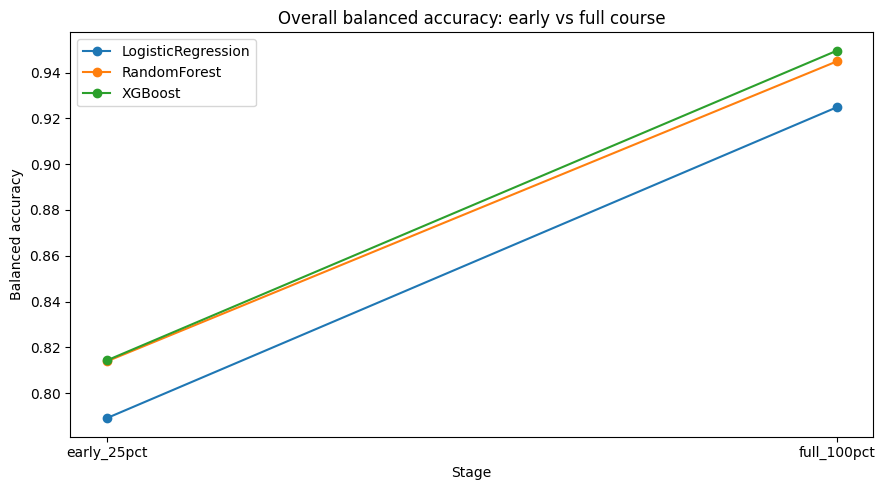

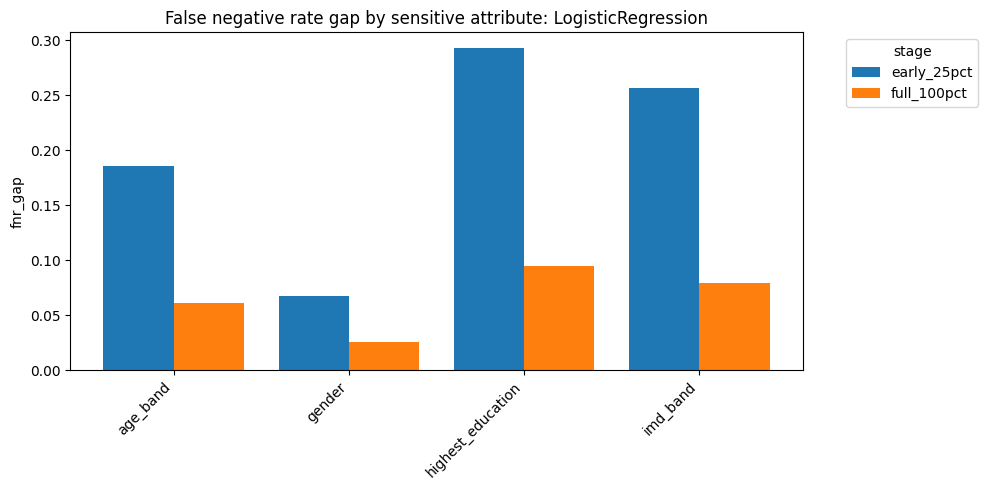

Saved: oulad_outputs/fnr_gap_LogisticRegression.png


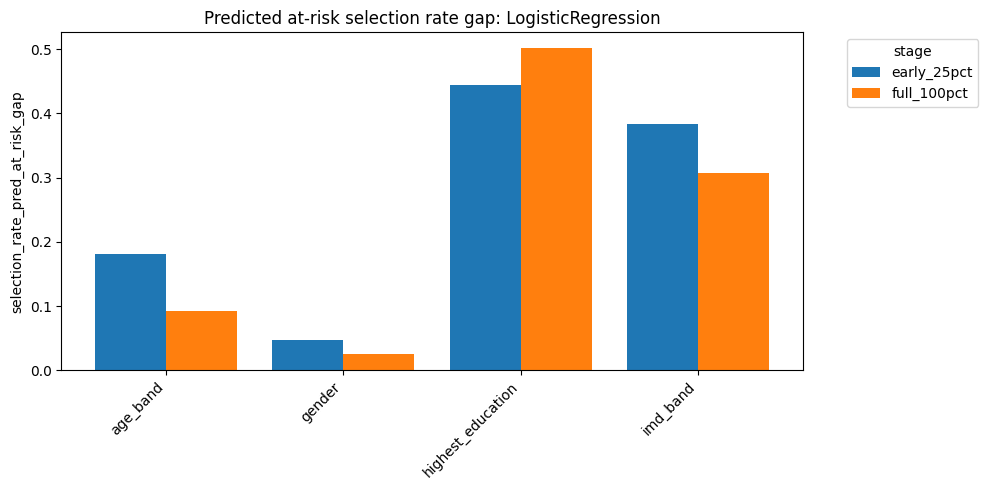

Saved: oulad_outputs/selection_rate_gap_LogisticRegression.png


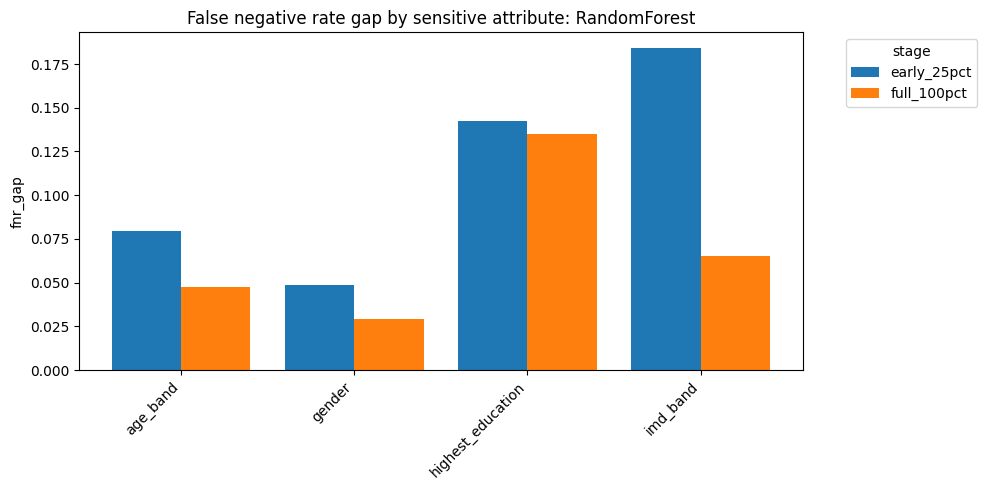

Saved: oulad_outputs/fnr_gap_RandomForest.png


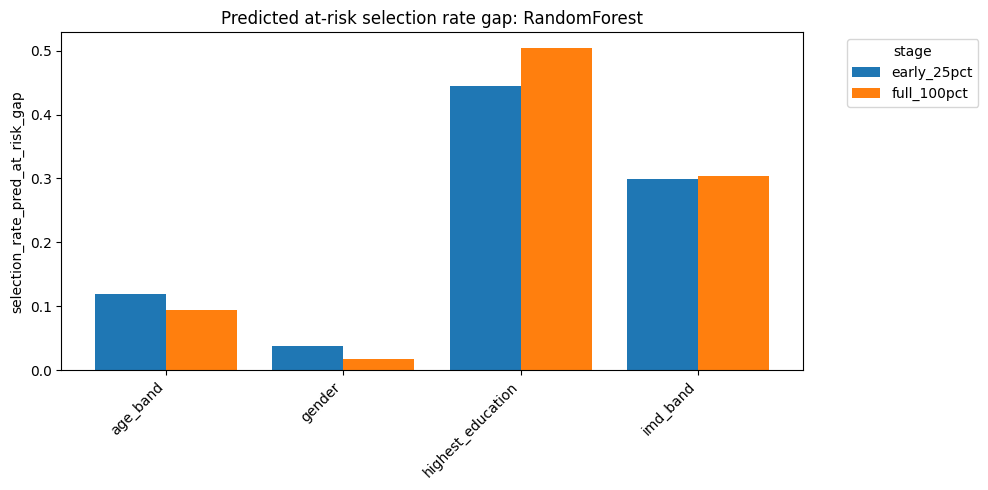

Saved: oulad_outputs/selection_rate_gap_RandomForest.png


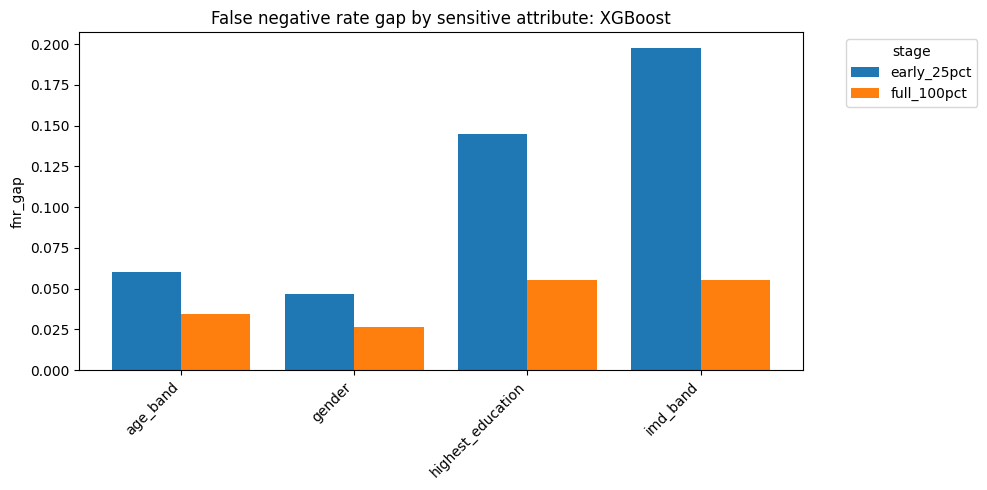

Saved: oulad_outputs/fnr_gap_XGBoost.png


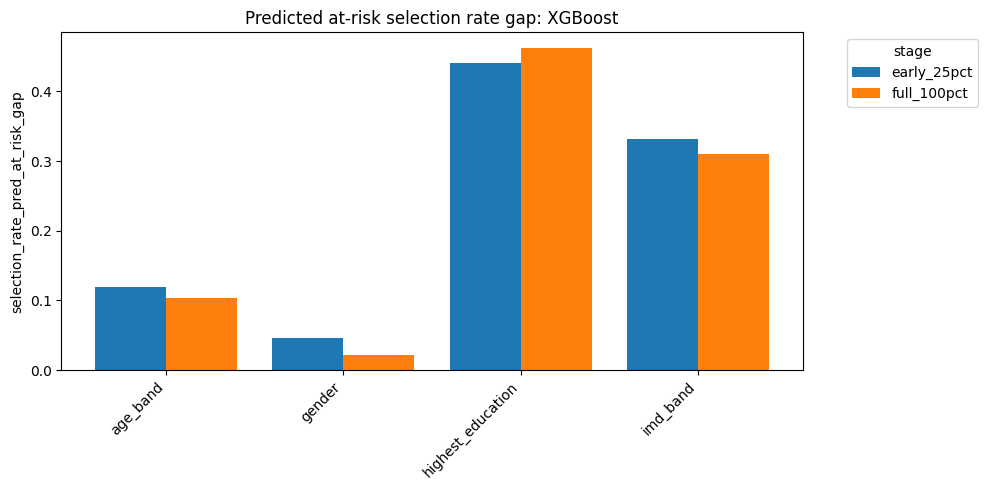

Saved: oulad_outputs/selection_rate_gap_XGBoost.png


In [6]:
from src.fairness import run_fairness_analysis, fairness_gap_summary, inspect_chosen_model
subgroup_early = run_fairness_analysis("early_25pct", early_test, models_early)
subgroup_full  = run_fairness_analysis("full_100pct", full_test,  models_full)
subgroup_metrics = pd.concat([subgroup_early, subgroup_full], ignore_index=True)
fairness_gaps = fairness_gap_summary(subgroup_metrics)
display(subgroup_metrics.head(30))
display(fairness_gaps.sort_values(["model", "sensitive_attr", "stage"]))

CHOSEN_MODEL = "RandomForest" if "RandomForest" in models_early else list(models_early)[0]
from src.fairness import inspect_chosen_model

display(inspect_chosen_model(subgroup_metrics, CHOSEN_MODEL))
from pathlib import Path
OUTPUT_DIR = Path("/content/oulad_outputs") if Path("/content").exists() else Path("oulad_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from src.visualization import plot_overall_performance, plot_fairness_gaps
plot_overall_performance(performance_table, OUTPUT_DIR)
plot_fairness_gaps(fairness_gaps, OUTPUT_DIR)

## Explainability

Skipping SHAP for LogisticRegression: model is not tree-based.
Saved: oulad_outputs/shap_RandomForest_early_25pct.png


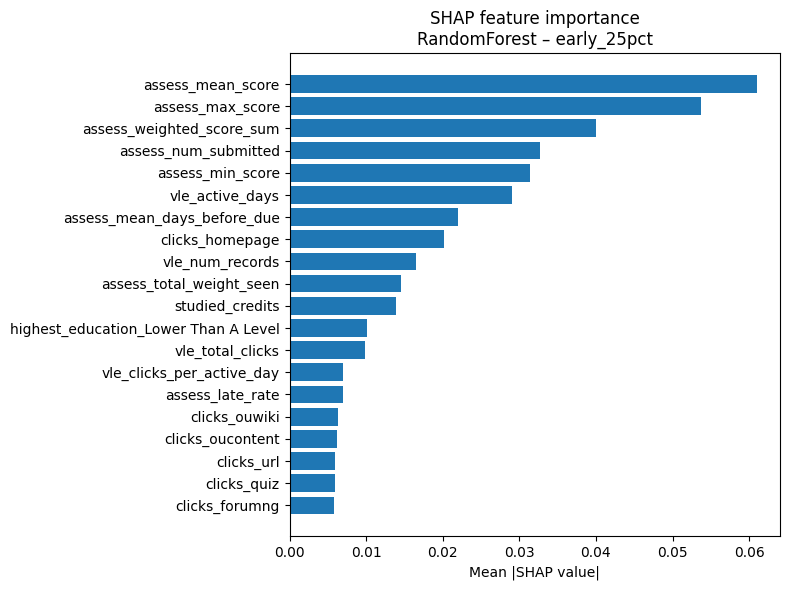

Saved: oulad_outputs/shap_summary_RandomForest_early_25pct.png


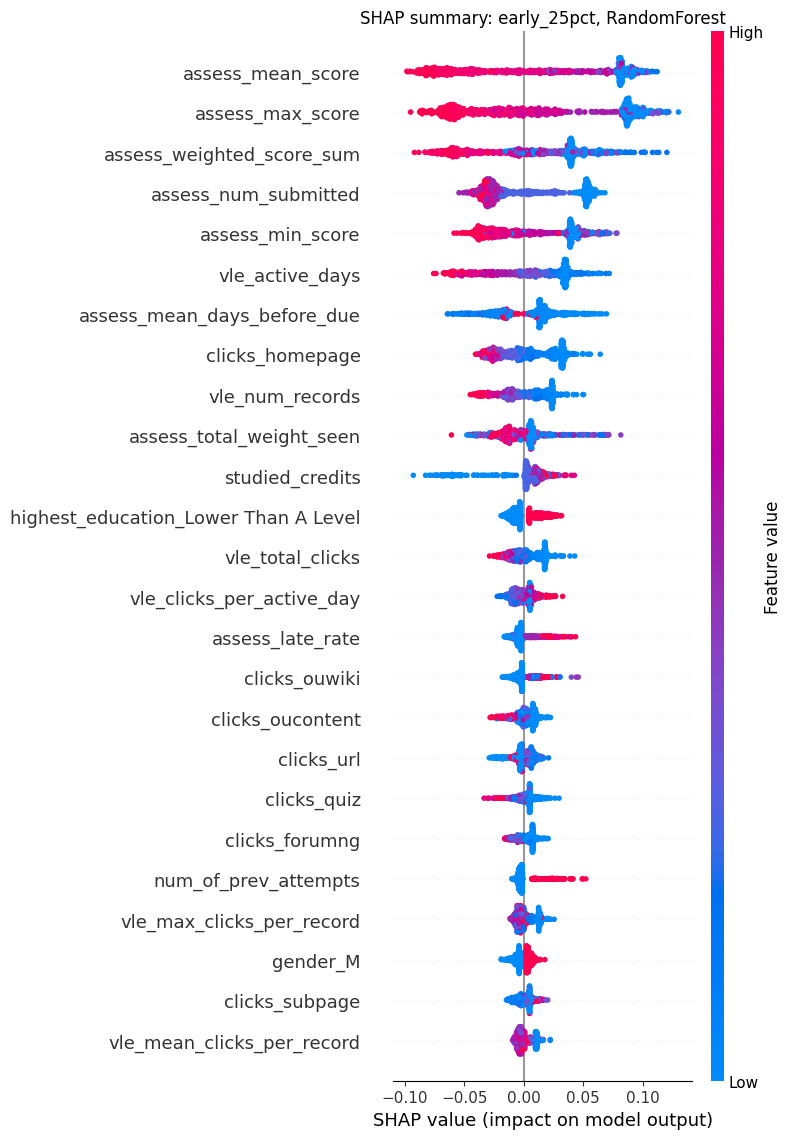

Saved: oulad_outputs/shap_XGBoost_early_25pct.png


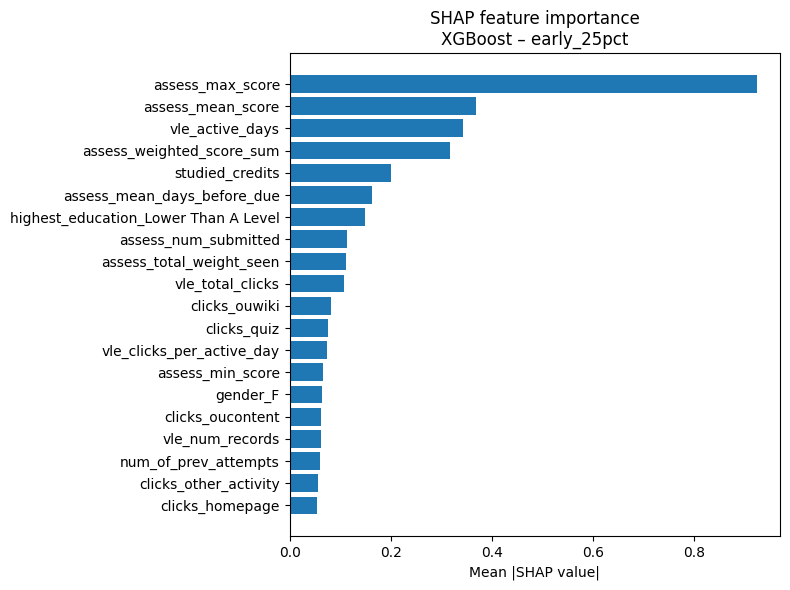

Saved: oulad_outputs/shap_summary_XGBoost_early_25pct.png


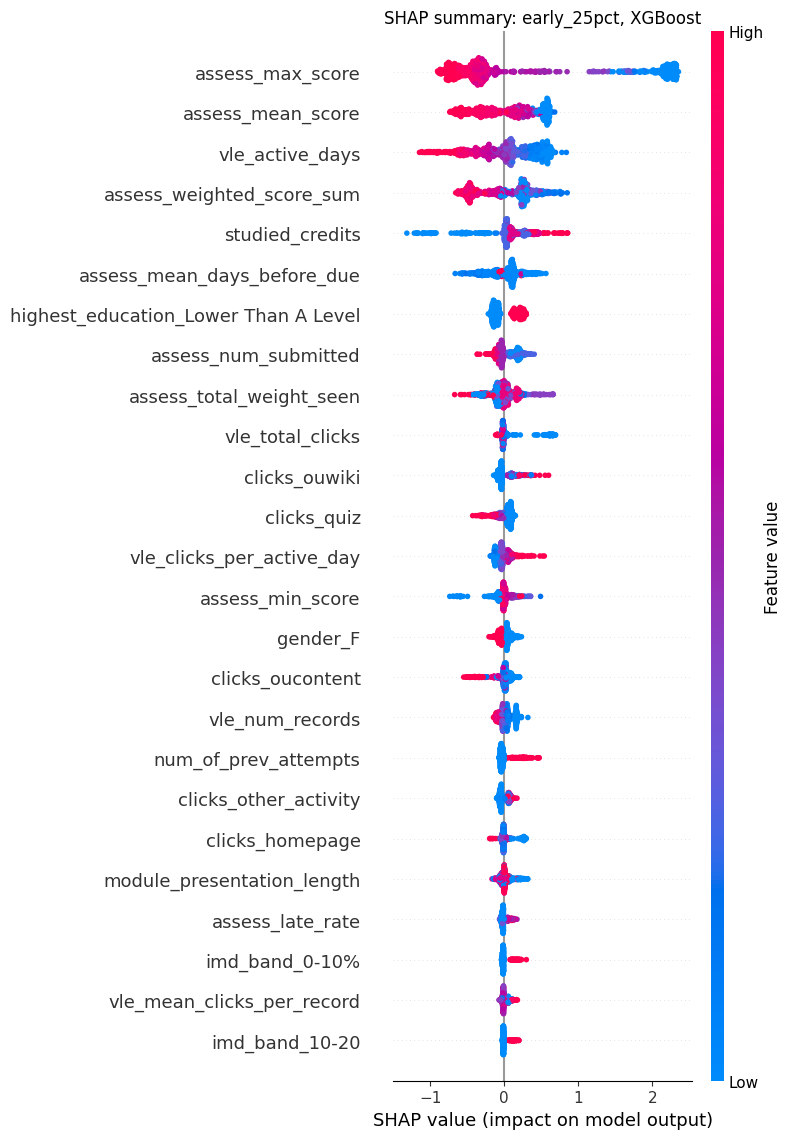

Skipping SHAP for LogisticRegression: model is not tree-based.
Saved: oulad_outputs/shap_RandomForest_full_100pct.png


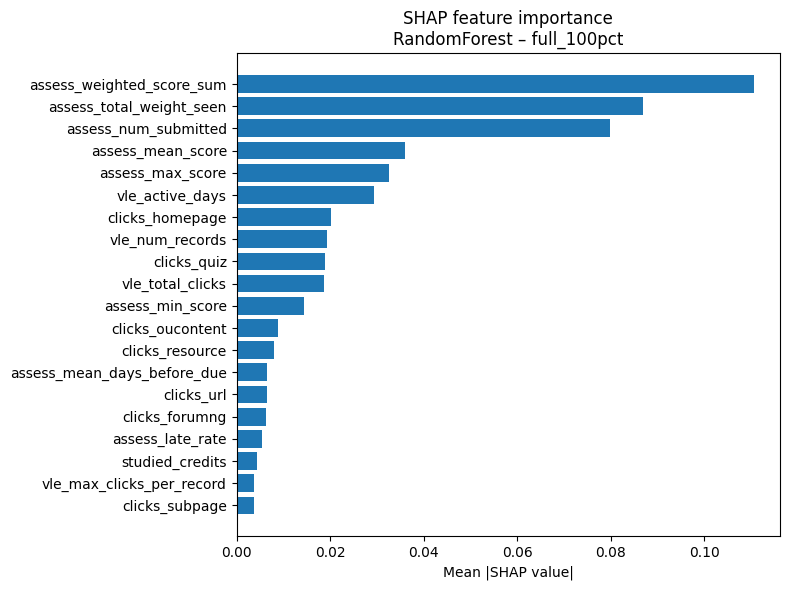

Saved: oulad_outputs/shap_summary_RandomForest_full_100pct.png


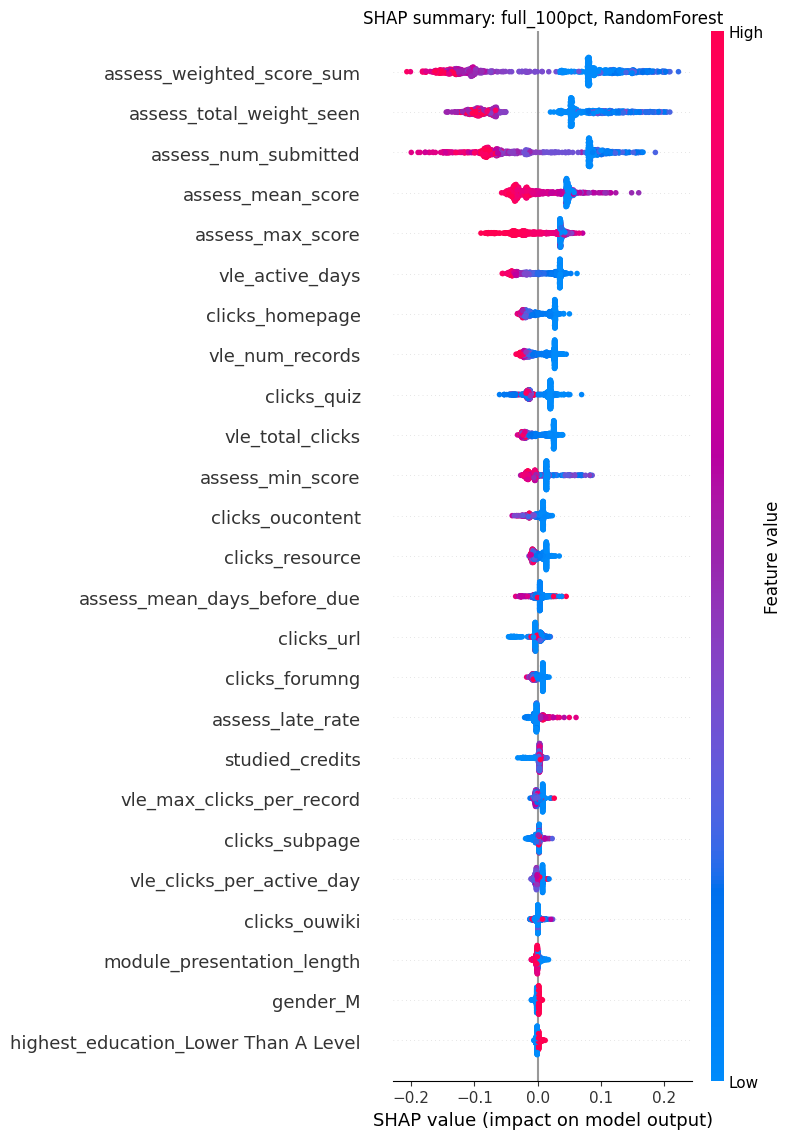

Saved: oulad_outputs/shap_XGBoost_full_100pct.png


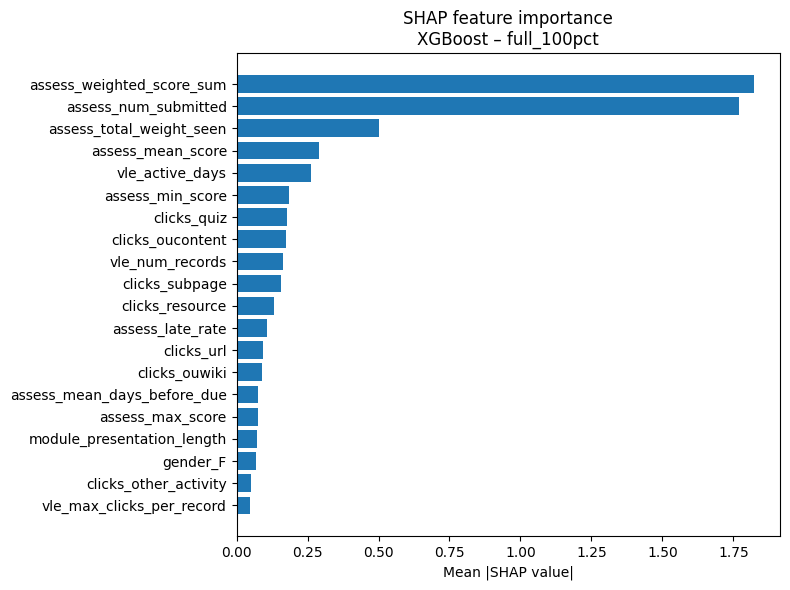

Saved: oulad_outputs/shap_summary_XGBoost_full_100pct.png


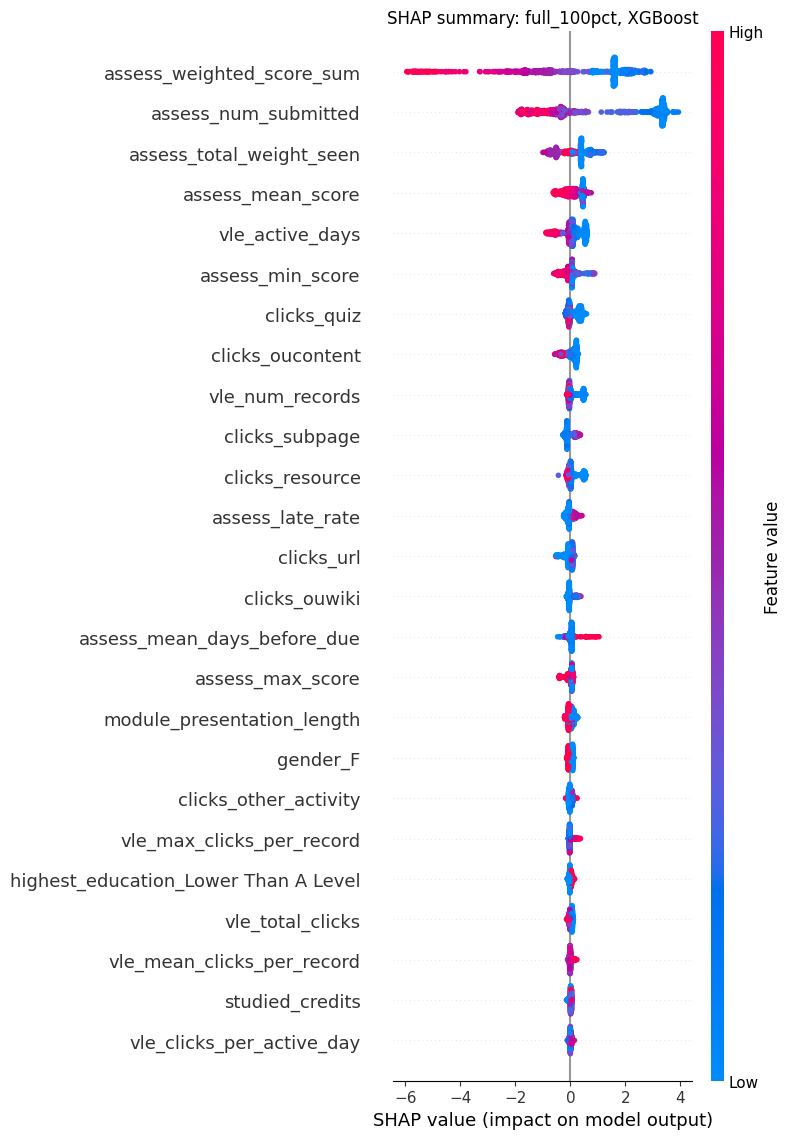

Saved: oulad_outputs/family_importance_RandomForest_early_25pct.png


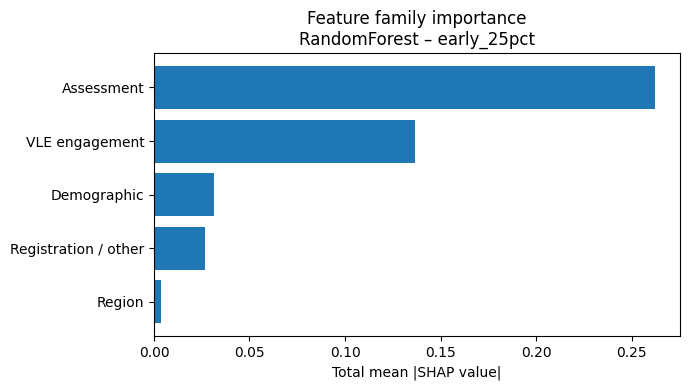

Saved: oulad_outputs/family_importance_RandomForest_full_100pct.png


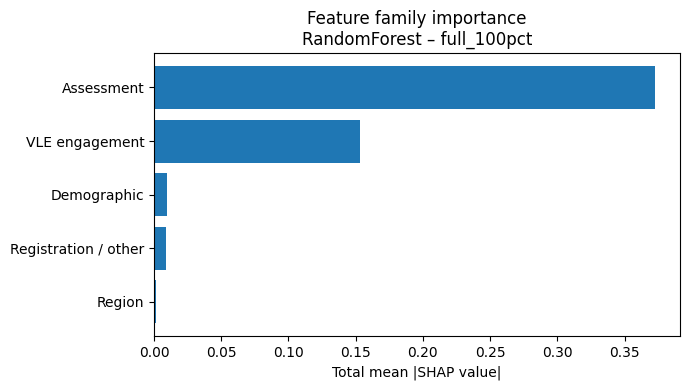

Saved: oulad_outputs/family_importance_XGBoost_early_25pct.png


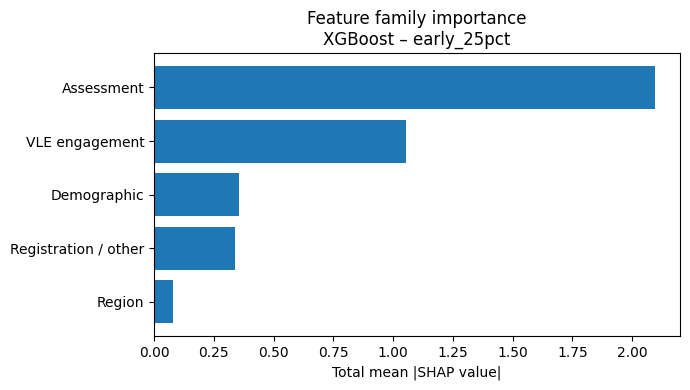

Saved: oulad_outputs/family_importance_XGBoost_full_100pct.png


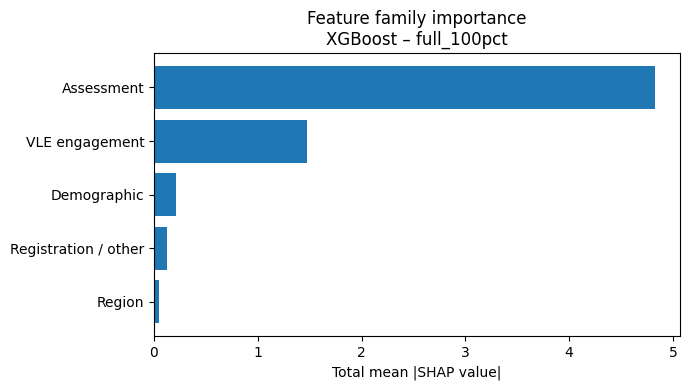

Saved: oulad_outputs/shap_subgroup_RandomForest_early_25pct_highest_education.png


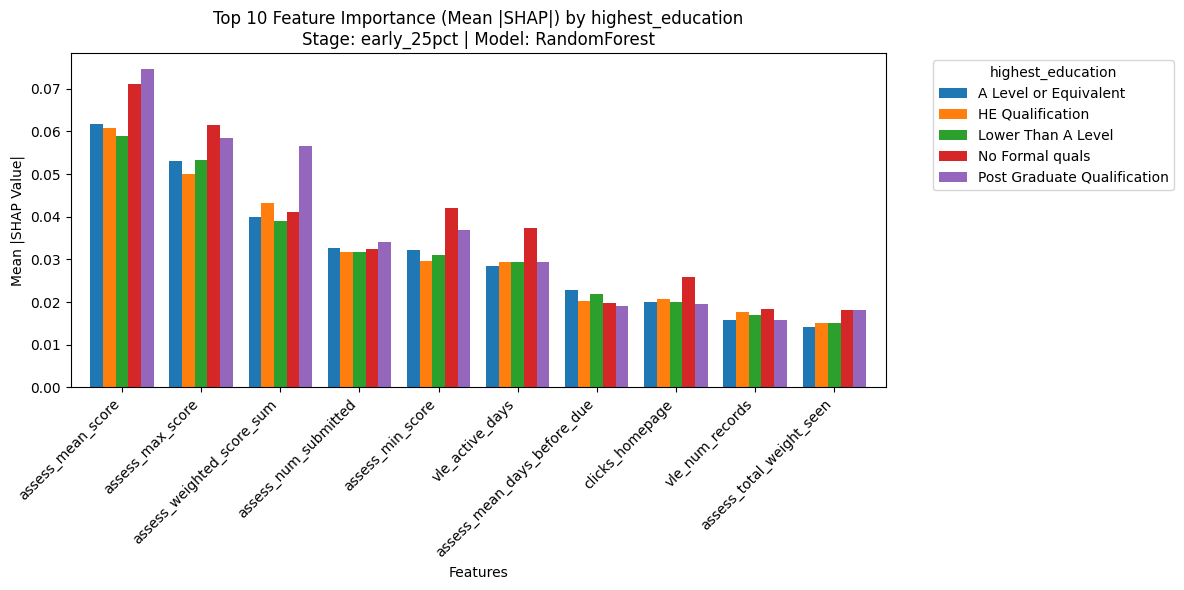

Saved: oulad_outputs/shap_subgroup_RandomForest_early_25pct_imd_band.png


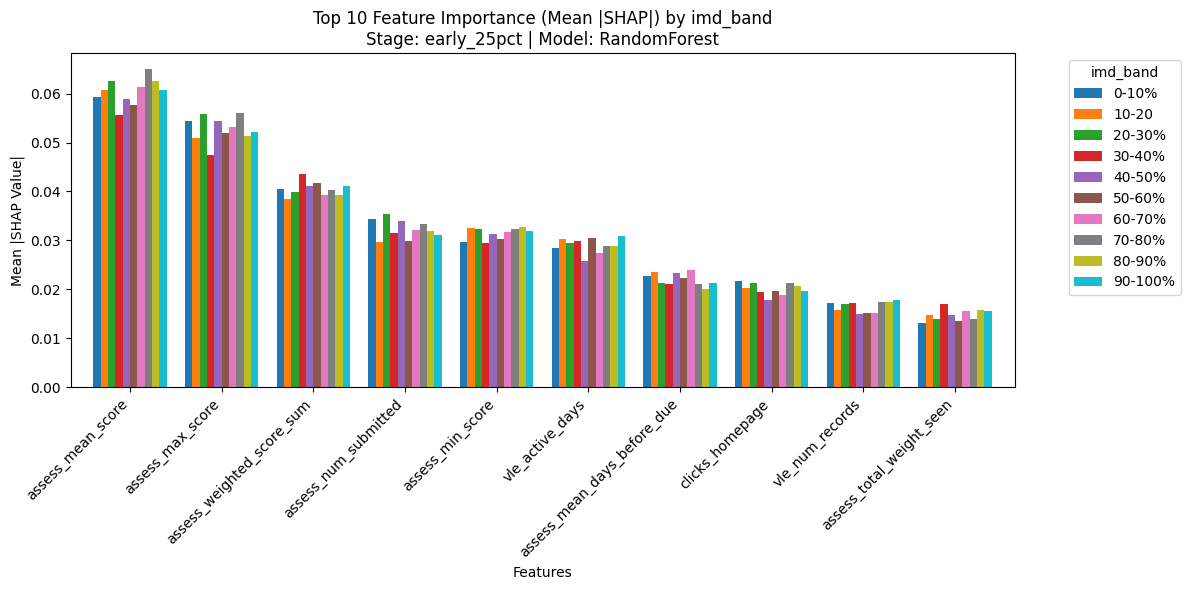

Saved: oulad_outputs/pfi_RandomForest_early_25pct.png


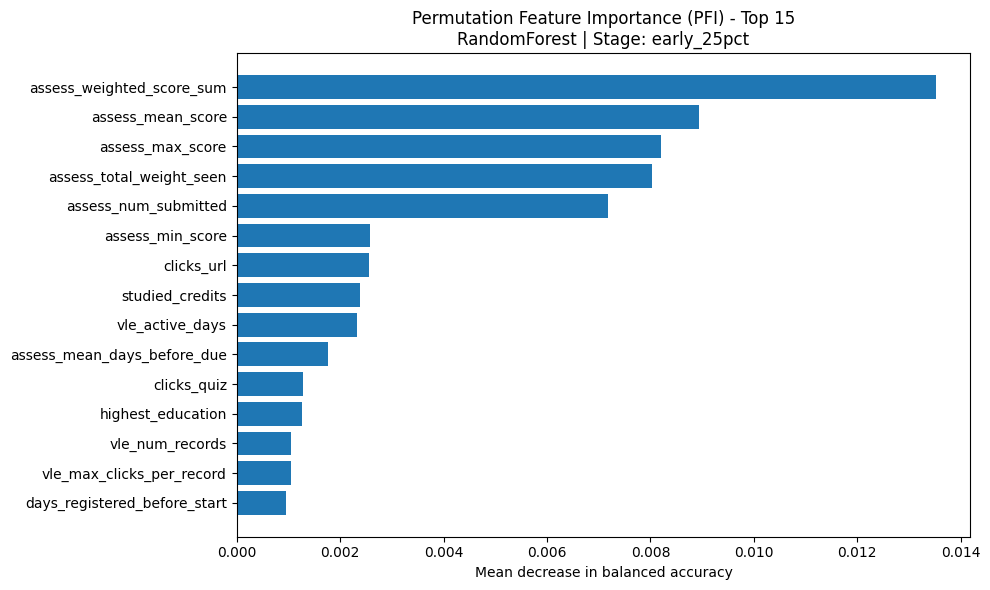

Saved: oulad_outputs/pfi_RandomForest_full_100pct.png


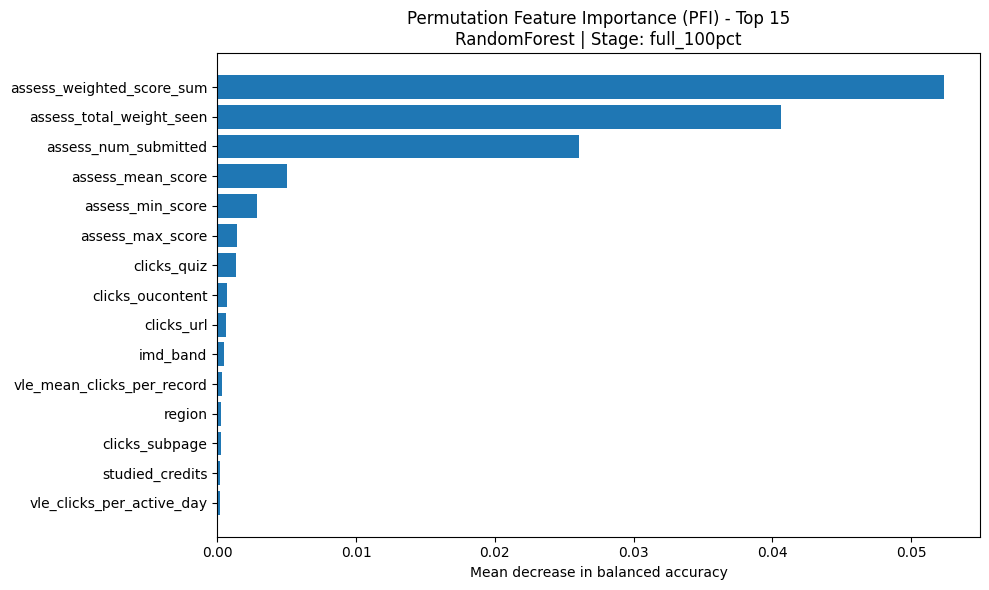

Saved: oulad_outputs/pdp_RandomForest_early_25pct.png


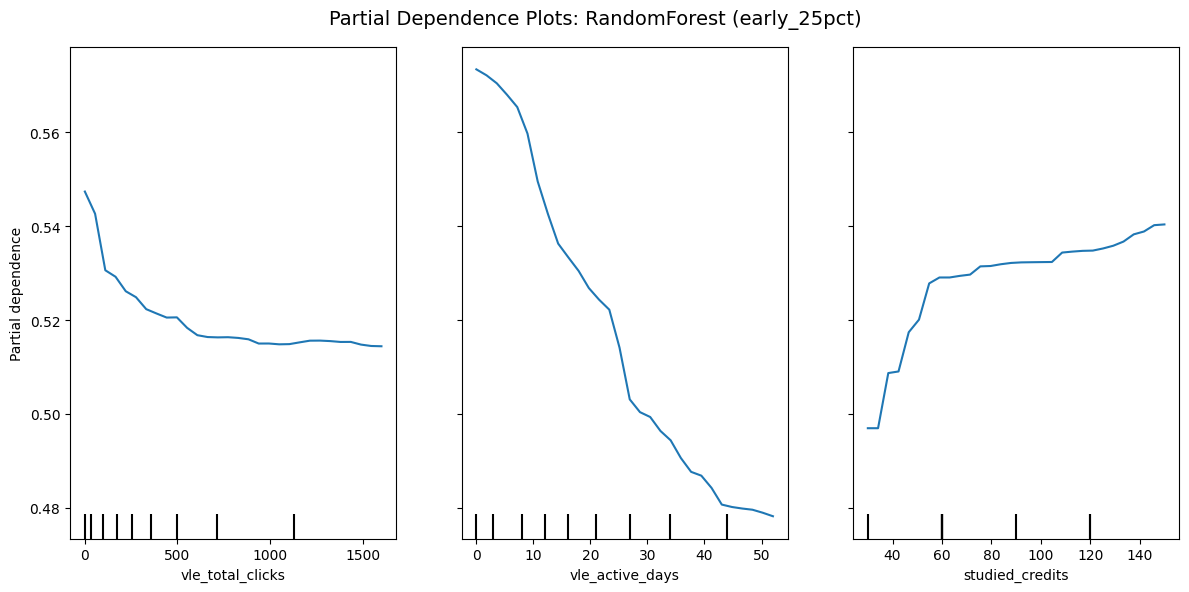

Saved: oulad_outputs/pdp_RandomForest_full_100pct.png


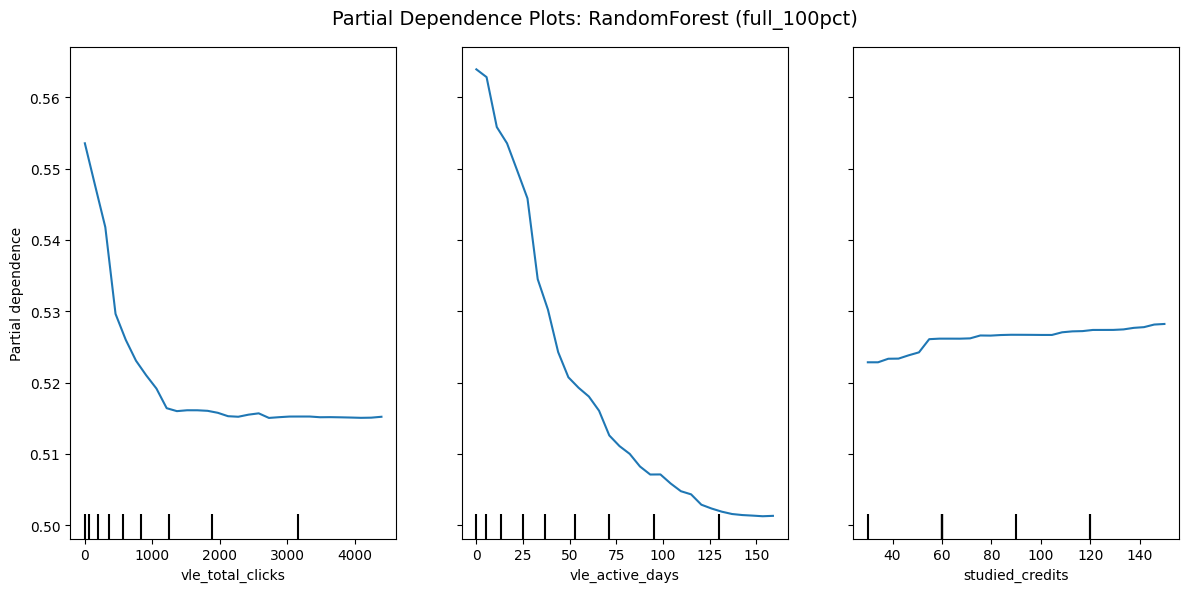

In [7]:
from src.explainability import (
    run_shap_for_tree_model,
    compute_family_importance,
    plot_family_importance,
    subgroup_shap_comparison,
    run_permutation_importance,
    run_partial_dependence,
)

RUN_SHAP = True
shap_results = {}
if RUN_SHAP:
    for model_name, pipe in models_early.items():
        shap_results[(model_name, "early_25pct")] = run_shap_for_tree_model(
            pipe,
            early_test,
            "early_25pct",
            model_name,
            output_dir=OUTPUT_DIR,
            shap_available=SHAP_AVAILABLE,
        )
    for model_name, pipe in models_full.items():
        shap_results[(model_name, "full_100pct")] = run_shap_for_tree_model(
            pipe,
            full_test,
            "full_100pct",
            model_name,
            output_dir=OUTPUT_DIR,
            shap_available=SHAP_AVAILABLE,
        )

family_importance = compute_family_importance(shap_results)
plot_family_importance(family_importance, output_dir=OUTPUT_DIR)

if "RandomForest" in models_early and "RandomForest" in models_full:
    if SHAP_AVAILABLE:
        subgroup_shap_comparison(
            models_early["RandomForest"],
            early_test,
            "highest_education",
            "early_25pct",
            "RandomForest",
            shap_available=SHAP_AVAILABLE,
            output_dir=OUTPUT_DIR,
        )
        subgroup_shap_comparison(
            models_early["RandomForest"],
            early_test,
            "imd_band",
            "early_25pct",
            "RandomForest",
            shap_available=SHAP_AVAILABLE,
            output_dir=OUTPUT_DIR,
        )
    else:
        print("Skipping subgroup SHAP comparison because SHAP is unavailable.")

    pfi_early = run_permutation_importance(
        models_early["RandomForest"],
        early_test,
        "early_25pct",
        "RandomForest",
        output_dir=OUTPUT_DIR,
    )
    pfi_full = run_permutation_importance(
        models_full["RandomForest"],
        full_test,
        "full_100pct",
        "RandomForest",
        output_dir=OUTPUT_DIR,
    )

    pdp_features = ["vle_total_clicks", "vle_active_days", "studied_credits"]
    valid_features_early = [f for f in pdp_features if f in early_test.columns]
    valid_features_full = [f for f in pdp_features if f in full_test.columns]

    if valid_features_early:
        run_partial_dependence(
            models_early["RandomForest"],
            early_test,
            "early_25pct",
            "RandomForest",
            valid_features_early,
            output_dir=OUTPUT_DIR,
        )
    if valid_features_full:
        run_partial_dependence(
            models_full["RandomForest"],
            full_test,
            "full_100pct",
            "RandomForest",
            valid_features_full,
            output_dir=OUTPUT_DIR,
        )
else:
    print("RandomForest is not available in both early and full models for extra explainability.")


In [ ]:
from src.reporting import export_tables
export_tables(performance_table, subgroup_metrics, fairness_gaps,
              family_importance=family_importance, output_dir=OUTPUT_DIR)


Saved output files to: oulad_outputs
 - oulad_outputs/fnr_gap_XGBoost.png
 - oulad_outputs/selection_rate_gap_LogisticRegression.png
 - oulad_outputs/family_importance_RandomForest_full_100pct.png
 - oulad_outputs/fnr_gap_RandomForest.png
 - oulad_outputs/overall_balanced_accuracy_by_stage.png
 - oulad_outputs/family_importance_RandomForest_early_25pct.png
 - oulad_outputs/family_importance_XGBoost_full_100pct.png
 - oulad_outputs/shap_subgroup_highest_education_early_25pct_RandomForest.png
 - oulad_outputs/pfi_early_25pct_RandomForest.png
 - oulad_outputs/family_importance_XGBoost_early_25pct.png
 - oulad_outputs/feature_family_importance.csv
 - oulad_outputs/pdp_full_100pct_RandomForest.png
 - oulad_outputs/shap_XGBoost_early_25pct.png
 - oulad_outputs/shap_XGBoost_full_100pct.png
 - oulad_outputs/fnr_gap_LogisticRegression.png
 - oulad_outputs/shap_summary_full_100pct_RandomForest.png
 - oulad_outputs/fairness_gaps.csv
 - oulad_outputs/shap_RandomForest_early_25pct.png
 - oulad_out